# Additional visualizations not in the paper

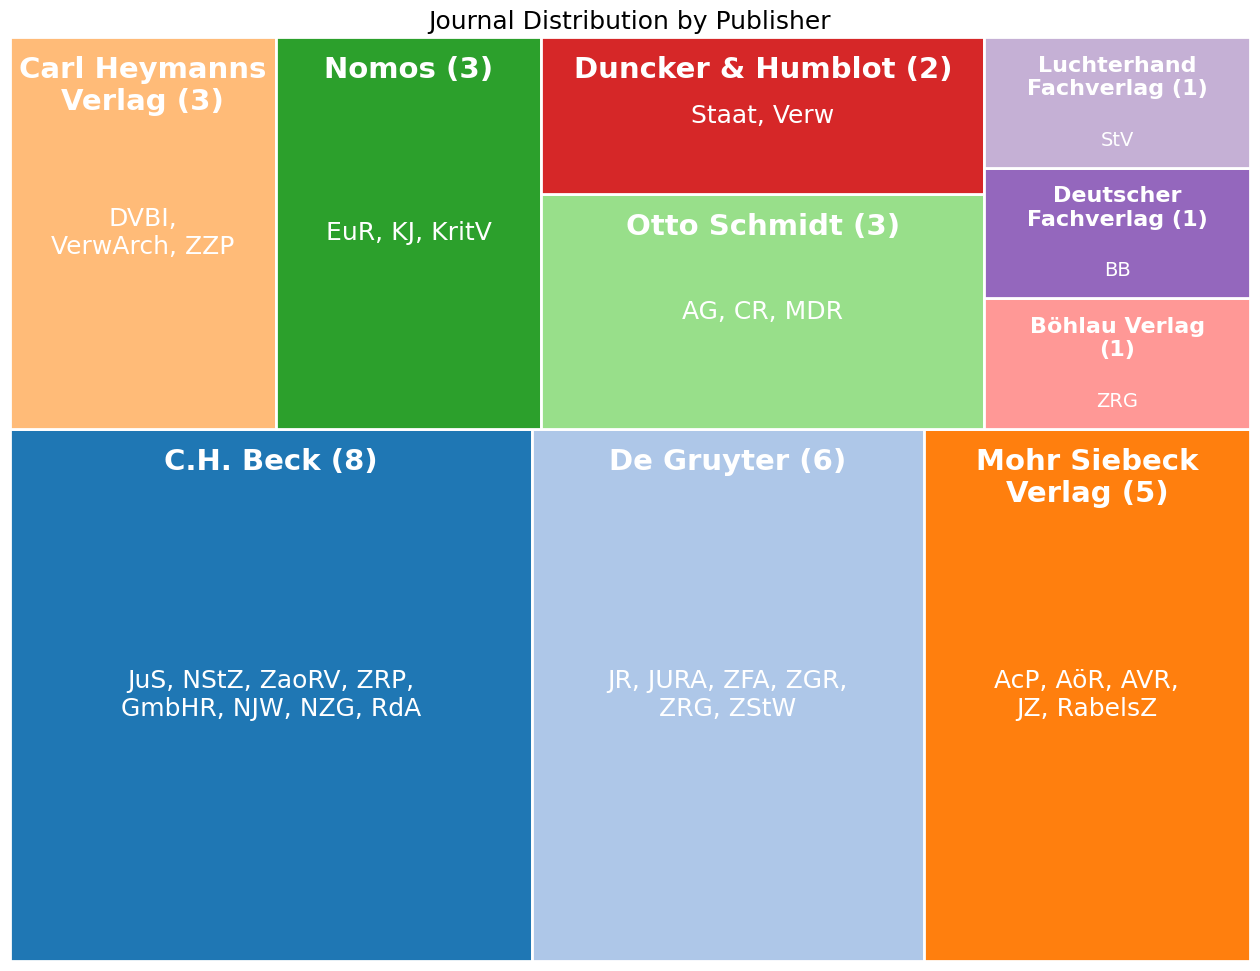

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap

def draw_treemap_large(data, ax):
    """
    Draws a treemap with larger fonts and text wrapping.
    """
    # Sort data by size descending for better packing
    data = sorted(data, key=lambda x: x['size'], reverse=True)
    
    # Recursive function to calculate rectangle coordinates (Slice-and-Dice)
    def layout(rect, items):
        if not items:
            return []
        
        rx, ry, rw, rh = rect
        
        if len(items) == 1:
            return [(items[0], rect)]
        
        # Split items into two groups with approximately equal weight
        half_size = sum(i['size'] for i in items) / 2.0
        acc = 0
        split_idx = 0
        for i, item in enumerate(items):
            acc += item['size']
            if acc >= half_size:
                split_idx = i + 1
                break
        
        # Refine split index to get closer to half
        if split_idx > 1:
            prev_acc = acc - items[split_idx-1]['size']
            if abs(half_size - prev_acc) < abs(acc - half_size):
                split_idx -= 1

        group1 = items[:split_idx]
        group2 = items[split_idx:]
        
        weight1 = sum(i['size'] for i in group1)
        weight2 = sum(i['size'] for i in group2)
        total_w = weight1 + weight2
        
        if total_w == 0: return []

        # Split along the longer dimension to maintain square-ish aspect ratios
        if rw > rh:
            w1 = rw * (weight1 / total_w)
            rect1 = (rx, ry, w1, rh)
            rect2 = (rx + w1, ry, rw - w1, rh)
        else:
            h1 = rh * (weight1 / total_w)
            # Stack from bottom
            rect1 = (rx, ry, rw, h1)
            rect2 = (rx, ry + h1, rw, rh - h1)
            
        return layout(rect1, group1) + layout(rect2, group2)

    # Generate coordinates for 100x100 canvas
    rects = layout((0, 0, 100, 100), data)
    
    # Styling
    cmap = plt.get_cmap('tab20') # Color palette
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis('off')
    
    for i, (item, (rx, ry, rw, rh)) in enumerate(rects):
        color = cmap(i % 20)
        
        # Draw Rectangle
        rect = patches.Rectangle((rx, ry), rw, rh, linewidth=2, edgecolor='white', facecolor=color)
        ax.add_patch(rect)
        
        # Calculate wrap width based on box width (heuristic)
        wrap_width = max(10, int(rw / 1.5))

        # Adaptive font sizing based on box dimensions
        # Use smaller fonts for smaller boxes to avoid overlap
        box_area = rw * rh
        if box_area < 200:  # Very small boxes
            publisher_fontsize = 12
            journal_fontsize = 10
            is_small_box = True
        elif box_area < 400:  # Small boxes
            publisher_fontsize = 16
            journal_fontsize = 14
            is_small_box = True
        else:  # Normal/large boxes
            publisher_fontsize = 21
            journal_fontsize = 18
            is_small_box = False

        # Add Publisher Label (Top) with journal count - Adaptive Font & Wrapped
        publisher_label = f"{item['label']} ({item['size']})"
        publisher_text = textwrap.fill(publisher_label, width=wrap_width)
        ax.text(rx + rw/2, ry + rh - 2, publisher_text, 
                ha='center', va='top', fontsize=publisher_fontsize, fontweight='bold', color='white')
        
        # Add Journals - Adaptive Font & Wrapped
        content_text = ", ".join(item['content'])
        content_text = textwrap.fill(content_text, width=wrap_width)
        
        # Only show text if box is big enough
        if rw > 12 and rh > 12:
            if is_small_box:
                # Align to bottom for small boxes to avoid overlap
                ax.text(rx + rw/2, ry + 2, content_text, 
                        ha='center', va='bottom', fontsize=journal_fontsize, color='white')
            else:
                # Center for large boxes
                ax.text(rx + rw/2, ry + rh/2, content_text, 
                        ha='center', va='center', fontsize=journal_fontsize, color='white')

# --- Data Setup ---
raw_data = {
  "Böhlau Verlag": ["ZRG"],
  "Carl Heymanns Verlag": ["DVBI", "VerwArch", "ZZP"],
  "C.H. Beck": ["JuS", "NStZ", "ZaoRV", "ZRP", "GmbHR", "NJW", "NZG", "RdA"],
  "De Gruyter": ["JR", "JURA", "ZFA", "ZGR", "ZRG", "ZStW"],
  "Deutscher Fachverlag": ["BB"],
  "Duncker & Humblot": ["Staat", "Verw"],
  "Luchterhand Fachverlag": ["StV"],
  "Mohr Siebeck Verlag": ["AcP", "AöR", "AVR", "JZ", "RabelsZ"],
  "Nomos": ["EuR", "KJ", "KritV"],
  "Otto Schmidt": ["AG", "CR", "MDR"]
}

# Prepare list of dictionaries
plot_data = []
for publisher, journals in raw_data.items():
    plot_data.append({
        'label': publisher,
        'size': len(journals),
        'content': journals
    })

# --- Plotting ---
fig, ax = plt.subplots(figsize=(16, 12)) # Increased figure size further
draw_treemap_large(plot_data, ax)
plt.title("Journal Distribution by Publisher", fontsize=18)
plt.show()

## Calculate library holdings of law journals in ZDB

In [17]:
import json
from collections import defaultdict
import re
import csv

# Load reference abbreviations from the CSV
reference_abbreviations = {}
with open('../data/web_lists/juristische-zeitschriften-issn-berichtigt.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        journal = row['journal'].strip()
        abbrev = row['abbreviation'].strip()
        if journal and abbrev:
            # Store by journal title
            reference_abbreviations[journal.lower()] = abbrev
            # Also create normalized version without special chars for fuzzy matching
            normalized_journal = re.sub(r'[^\w\s]', '', journal.lower())
            reference_abbreviations[normalized_journal] = abbrev

def find_canonical_abbreviation(title, alternative_titles, other_title_info):
    """
    Find the best abbreviation from alternativeTitle and otherTitleInformation.
    Priority order:
    1. Short abbreviations from alternativeTitle/otherTitleInformation (e.g., ZRG GA, NJW)
    2. Exact reference CSV match
    3. Normalized/truncated reference CSV match
    4. Heuristic fallback
    """
    # FIRST PRIORITY: Check for short abbreviations in alternative titles and otherTitleInformation
    short_abbreviations = []
    
    # Check alternative titles for SHORT abbreviations
    if alternative_titles:
        for alt_title in alternative_titles:
            # Skip long descriptive titles with parentheses
            if '(' in alt_title:
                continue
            
            cleaned = alt_title.strip()
            words = re.split(r'\s+', cleaned)
            
            # Single word candidates - HIGHEST PRIORITY
            if len(words) == 1 and len(cleaned) <= 10:
                short_abbreviations.append(cleaned)
            # Multi-word but very short (like "ZRG GA", "ZRG KA")
            elif len(words) <= 3 and len(cleaned) <= 15 and sum(1 for c in cleaned if c.isupper()) >= len(cleaned.replace(' ', '')) * 0.5:
                short_abbreviations.append(cleaned)
    
    # Check otherTitleInformation (often has abbreviation before semicolon)
    if other_title_info:
        for other_info in other_title_info:
            # Extract text before semicolon
            if ';' in other_info:
                before_semicolon = other_info.split(';')[0].strip()
                # Check if it's a short abbreviation
                words = re.split(r'\s+', before_semicolon)
                if len(words) == 1 and len(before_semicolon) <= 10:
                    short_abbreviations.append(before_semicolon)
    
    # If we found short abbreviations, return the shortest one
    if short_abbreviations:
        return min(short_abbreviations, key=len)
    
    # SECOND PRIORITY: Check reference CSV for exact match
    if title:
        # Try exact match (case-insensitive)
        title_lower = title.lower()
        if title_lower in reference_abbreviations:
            return reference_abbreviations[title_lower]
        
        # Try normalized match (without special characters)
        normalized_title = re.sub(r'[^\w\s]', '', title_lower)
        if normalized_title in reference_abbreviations:
            return reference_abbreviations[normalized_title]
        
        # Try matching against truncated title (before punctuation)
        match = re.match(r'^([^:,;.]+)', title)
        if match:
            truncated = match.group(1).strip().lower()
            if truncated in reference_abbreviations:
                return reference_abbreviations[truncated]
    
    # THIRD PRIORITY: Heuristic fallback
    abbreviation_candidates = []
    
    # Check alternative titles for shorter versions
    if alternative_titles:
        for alt_title in alternative_titles:
            if '(' in alt_title:
                continue
            cleaned = alt_title.strip()
            # Multi-word alternatives - only if significantly shorter than title
            if title and len(cleaned) < len(title) * 0.7:
                abbreviation_candidates.append(cleaned)
    
    # Use part of title before punctuation (except hyphen)
    if title:
        match = re.match(r'^([^:,;.]+)', title)
        if match:
            title_part = match.group(1).strip()
            # Only use if it's reasonably short
            if len(title_part) <= 50:
                abbreviation_candidates.append(title_part)
    
    # If we found candidates, return the shortest one
    if abbreviation_candidates:
        best_abbrev = min(abbreviation_candidates, key=len)
        # If result is longer than title, use title
        if title and len(best_abbrev) > len(title):
            return title
        return best_abbrev
    
    # Fallback to title
    return title if title else ''

# Load the ZDB data
input_file = '../data/zdb/zdb-ger-law-issn-1945-2024.json'
output_holdings_file = '../data/zdb/zdb-ger-law-holdings.json'
output_isil_file = '../data/zdb/isil.json'

print("Loading ZDB data...")
with open(input_file, 'r', encoding='utf-8') as f:
    zdb_data = json.load(f)

print(f"Loaded {len(zdb_data)} journal entries")
print(f"Loaded {len(reference_abbreviations)} reference abbreviations")

# Process the data
holdings_data = []
isil_lookup = {}

for entry in zdb_data:
    # Skip entries without hasItem
    if 'hasItem' not in entry or not entry['hasItem']:
        continue
    
    # Extract title
    title = entry.get('title', '')
    
    # Extract canonical abbreviation
    alternative_titles = entry.get('alternativeTitle', [])
    other_title_info = entry.get('otherTitleInformation', [])
    abbreviation = find_canonical_abbreviation(title, alternative_titles, other_title_info)
    
    # Extract ISSN as array
    issn = entry.get('issn', [])
    
    # Extract unique ISIL values from hasItem
    isil_set = set()
    for item in entry['hasItem']:
        if 'heldBy' in item and 'isil' in item['heldBy']:
            isil = item['heldBy']['isil']
            isil_set.add(isil)
            
            # Build ISIL lookup table
            if isil not in isil_lookup:
                isil_lookup[isil] = {
                    'id': item['heldBy'].get('id', ''),
                    'label': item['heldBy'].get('label', '')
                }
    
    # Create holdings entry
    holdings_entry = {
        'title': title,
        'abbreviation': abbreviation,
        'issn': issn,
        'isil': sorted(list(isil_set))  # Sort for consistency
    }
    
    holdings_data.append(holdings_entry)

print(f"Processed {len(holdings_data)} journals with holdings")
print(f"Found {len(isil_lookup)} unique ISIL identifiers")

# Save holdings data
print(f"Saving holdings data to {output_holdings_file}...")
with open(output_holdings_file, 'w', encoding='utf-8') as f:
    json.dump(holdings_data, f, ensure_ascii=False, indent=2)

# Save ISIL lookup table
print(f"Saving ISIL lookup table to {output_isil_file}...")
with open(output_isil_file, 'w', encoding='utf-8') as f:
    json.dump(isil_lookup, f, ensure_ascii=False, indent=2)

print("Done!")

# Display some statistics
total_holdings = sum(len(entry['isil']) for entry in holdings_data)
avg_holdings = total_holdings / len(holdings_data) if holdings_data else 0

print(f"\nStatistics:")
print(f"- Total journals with holdings: {len(holdings_data)}")
print(f"- Total library holdings: {total_holdings}")
print(f"- Average holdings per journal: {avg_holdings:.2f}")
print(f"- Unique libraries (ISIL): {len(isil_lookup)}")

# Show sample entries with abbreviations
if holdings_data:
    print(f"\nSample holdings entries:")
    for i in range(min(10, len(holdings_data))):
        print(f"\n{i+1}. {holdings_data[i]['title']}")
        print(f"   Abbreviation: {holdings_data[i]['abbreviation']}")
        print(f"   ISSN: {holdings_data[i]['issn']}")
        print(f"   Holdings: {len(holdings_data[i]['isil'])} libraries")

Loading ZDB data...
Loaded 1692 journal entries
Loaded 807 reference abbreviations
Processed 943 journals with holdings
Found 249 unique ISIL identifiers
Saving holdings data to ../data/zdb/zdb-ger-law-holdings.json...
Saving ISIL lookup table to ../data/zdb/isil.json...
Done!

Statistics:
- Total journals with holdings: 943
- Total library holdings: 9334
- Average holdings per journal: 9.90
- Unique libraries (ISIL): 249

Sample holdings entries:

1. Gesetz- und Verordnungsblatt für Berlin
   Abbreviation: Gesetz- und Verordnungsblatt für Berlin
   ISSN: ['03439550']
   Holdings: 11 libraries

2. Civil liberties and police, Deutsche Ausgabe : Informationsdienst: Bürgerrechte und Polizeientwicklung
   Abbreviation: CILIP
   ISSN: ['01721895']
   Holdings: 6 libraries

3. Deutsche Steuer-Zeitung, Ausgabe A
   Abbreviation: DStZ
   ISSN: ['00120774']
   Holdings: 18 libraries

4. Bundeswehrverwaltung
   Abbreviation: BWV
   ISSN: ['00075957', '00075957']
   Holdings: 3 libraries

5. Arch

## Analyse

Find the 52 journals with the most holdings, filtered by non-journals (= having the strings in the title contained in the `exclude_title_parts` list)

In [18]:
import pandas as pd

# Load the holdings data
with open('../data/zdb/zdb-ger-law-holdings.json', 'r', encoding='utf-8') as f:
    holdings = json.load(f)

# Add holdings count to each entry
for entry in holdings:
    entry['holdings_count'] = len(entry['isil'])

# Define exclusion list (case-insensitive)
exclude_title_parts = ['gesetzblatt', 'entscheidungen', 'bundesanzeiger', 'steuerblatt', 'arbeitsblatt']

# Filter out entries with excluded terms in the title
filtered_holdings = [
    entry for entry in holdings
    if not any(excluded in entry['title'].lower() for excluded in exclude_title_parts)
]

# Sort by holdings count (descending) and get top 52
top_journals = sorted(filtered_holdings, key=lambda x: x['holdings_count'], reverse=True)[:52]

# Sort by abbreviation for the final table
# Put empty abbreviations at the end
top_journals_sorted = sorted(top_journals, key=lambda x: (x['abbreviation'].lower() if x['abbreviation'] else 'zzzzzzz'))

# Create DataFrame
df = pd.DataFrame([
    {
        'Abbreviation': entry['abbreviation'],
        'Title': entry['title'],
        'Holdings': entry['holdings_count']
    }
    for entry in top_journals_sorted
])

# Save to CSV
output_csv = '../data/zdb/top-52-journals-by-holdings.csv'
df.to_csv(output_csv, index=False, encoding='utf-8')

# Display with left alignment for both data and headers, no index
df.style.hide(axis='index').set_properties(**{'text-align': 'left'}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
])

Abbreviation,Title,Holdings
AcP,Archiv für die civilistische Praxis,35
Arbeitsschutz,Arbeitsschutz,31
ARSP,Archiv für Rechts- und Sozialphilosophie,44
AöR,Archiv des öffentlichen Rechts,42
BASS,Bereinigte amtliche Sammlung der Schulvorschriften des Landes Nordrhein-Westfalen,29
BB,Betriebs-Berater,61
BBaubl,Bundesbaublatt,32
Das Parlament,Das Parlament,39
Der Städtetag,Der Städtetag,38
DStZ,Deutsche Steuer-Zeitung,31


## Venn Diagram: Benchmark Set vs Top 52 by Holdings

Benchmark Set: 52 journals
Top 52 by Holdings: 51 journals

Overlap: 11 journals
Only in Benchmark: 41 journals
Only in Top 52: 40 journals

Journals only in Benchmark Set:
  AG: Die Aktiengesellschaft
  AVR: Archiv des Volkerrechts
  AuR: Arbeit und Recht
  CR: Computer und Recht
  DB: DER BETRIEB
  DOV: Die öffentliche Verwaltung
  DStR: Deutsches Steuerrecht
  DVBI: Deutsches Verwaltungsblatt
  EuGRZ: Europäische Grundrechtezeitschrift
  EuR: Europarecht
  EuZW: Europäische Zeitschrift für Wirtschaftsrecht
  FamRZ: Zeitschrift für das gesamte Familienrecht
  GA: Goltdammers Archiv für  Strafrecht
  GmbHR: GmbH-Rundschau
  JR: Juristische Rundschau
  JURA: Juristische Ausbildung
  JZ: JuristenZeitung
  JuS: Juristische Schulung
  KritV: Kritische Vierteljahresschrift für Gesetzgebung und Rechtswissenschaft
  MDR: Monatsschrift für Deutsches Recht
  NStZ: Neue Zeitschrift für Strafrecht
  NVwZ: Neue Zeitschrift für Verwaltungsrecht
  NZA: Neue Zeitschrift für Arbeitsrecht
  NZG: Neue 

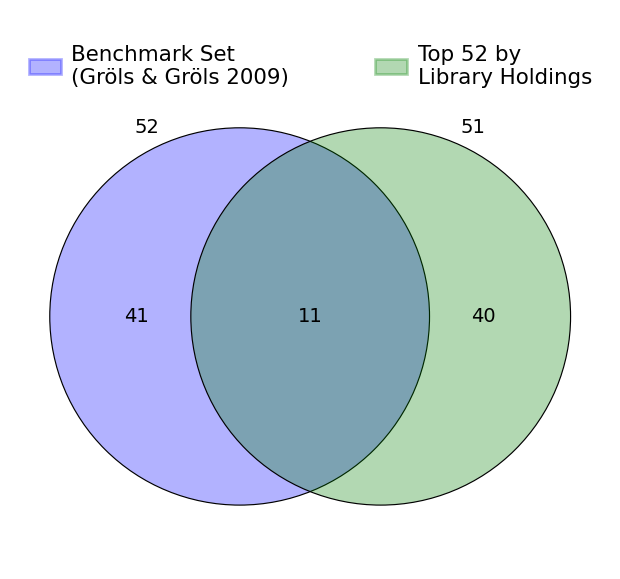

In [19]:
from venny4py.venny4py import venny4py
import pandas as pd

# Load benchmark set
benchmark_df = pd.read_csv('../data/benchmark/list-groels-groels-2009.csv')
benchmark_abbrevs = set(benchmark_df['abbreviation'].dropna().str.strip())

# Load top 52 journals by holdings
top52_df = pd.read_csv('../data/zdb/top-52-journals-by-holdings.csv')
top52_abbrevs = set(top52_df['Abbreviation'].dropna().str.strip())

# Special case: ZRG in benchmark represents all ZRG variants in top52
# Check if we need to normalize ZRG variants
zrg_variants_in_top52 = {abbr for abbr in top52_abbrevs if abbr.startswith('ZRG')}
if 'ZRG' in benchmark_abbrevs and zrg_variants_in_top52:
    # Replace ZRG with specific variants for fair comparison
    benchmark_abbrevs.discard('ZRG')
    benchmark_abbrevs.update(zrg_variants_in_top52)

# Create sets dictionary for venny4py
sets = {
    'Benchmark Set\n(Gröls & Gröls 2009)': benchmark_abbrevs,
    'Top 52 by\nLibrary Holdings': top52_abbrevs
}

# Generate Venn diagram
venny4py(sets)

# Print detailed comparison
print(f"Benchmark Set: {len(benchmark_abbrevs)} journals")
print(f"Top 52 by Holdings: {len(top52_abbrevs)} journals")
print(f"\nOverlap: {len(benchmark_abbrevs & top52_abbrevs)} journals")
print(f"Only in Benchmark: {len(benchmark_abbrevs - top52_abbrevs)} journals")
print(f"Only in Top 52: {len(top52_abbrevs - benchmark_abbrevs)} journals")

print(f"\nJournals only in Benchmark Set:")
only_benchmark = sorted(benchmark_abbrevs - top52_abbrevs)
for abbr in only_benchmark:
    title_row = benchmark_df[benchmark_df['abbreviation'] == abbr]
    if not title_row.empty:
        print(f"  {abbr}: {title_row.iloc[0]['title']}")

print(f"\nJournals only in Top 52 by Holdings:")
only_top52 = sorted(top52_abbrevs - benchmark_abbrevs)
for abbr in only_top52:
    title_row = top52_df[top52_df['Abbreviation'] == abbr]
    if not title_row.empty:
        print(f"  {abbr}: {title_row.iloc[0]['Title']} ({title_row.iloc[0]['Holdings']} holdings)")

## Intersection of G&G list and ZDB holdings
